# Transformer LLMs

A transformer is a deep learning architecture that was first introduced in the 2017 paper [Attention is All You Need](https://arxiv.org/abs/1706.03762). Transformers are designed for processing and predicting sequential data. They have had great success in natural language processing (NLP) tasks. Powerful LLMs such as DeepSeek, GPT, Claude and Gemini use Transformers. Transformers process sequential data using Attention networks.

### NLP Recap

<b>Tokenization</b> is the process of breaking down text into smaller unique units, called tokens. Tokens can be words, subwords, or even single characters. 

<b>Token Encoding</b> involves mapping the set of all unique tokens to integers. The set of all unique tokens is referred to as a vocabulary. 

<b>Token/Word Embedding</b> maps these token IDs to dense, continuous vectors in a feature space where spatial position captures semantic information. Similar tokens have similar embedding vectors. They are typically generated by trainable parameters within embedding layers in LLMs.

<img src="semantic_feature_space.png" width="800" align="center">

By studying RNN based language model like Seq2Seq, we learned that language can be understood through temporal dependencies. An RNN will process a sentence one word at a time, updating a hidden 'memory' state each time to retain information.

RNN and Transformer based language models are auto-regressive. To generate the next word in a response to some prompt, we rely on 2 things: 1). our prediction of the previous word and 2). some dense representation of the input prompt (RNN hidden memory state, Transformer's Encoder output). The first iteration/prediction uses `<sos>` token as our 'previous word'. 

## Advanced Preprocessing for LLMs


### Advanced Tokenization

In the previous lesson we used a simple spaCy tokenizer. It starts by splitting text on whitespace (spaces, tabs, newlines) and then applies specific rules to handle prefix symbols (`(`, `$`, `"`) and infix symbols (`)`, `km`, `,`).

More advanced tokenization methods are crucial to reduce out-of-vocabulary (OOV) problems by breaking down words into sequences of characters:

* <b>N-gram tokenizer</b>: split text into contiguous sequences of n items (words or characters). For example, bi-grams of the word "hello" are ["he", "el", "ll", "lo"]. Not common in mainstream LLMs. 

* <b>Byte-Pair Encoding (BPE)</b>: starts with a base vocabulary (usually characters) and iteratively merges the most frequent pairs to form subword units until a target vocabulary size is reached. E.g for the 2nd iteration we may focus on 2-character pairs, finding frequent subwords like 'in', 'of', 'im'. It is used in LLM models like GPT-2, GPT-3 and RoBERTa. BPE significantly reducing OOV issues while keeping the vocabulary size manageable. 

* <b>SentencePiece</b>

* <b>WordPiece</b>


### Token/Word Embedding 

Maps discrete token IDs to continuous dense vectors. This process is typically implemented as a learnable lookup table using modules like `torch.nn.Embedding` in PyTorch.
* <b>Embedding Matrix</b> has dimensions [`vocab_size`, `embedding_dim`], meaning it contains exactly `vocab_size`$\times$`embedding_dim` learnable parameters.
* <b>Learning Dynamics</b>: The embedding vectors are learned jointly with the rest of the model during training, allowing them to capture rich semantic and syntactic properties of language.

### Positional Embedding

Since transformer models do not inherently capture sequence order (unlike RNNs), positional embeddings are added to token embeddings to provide information about token order. There are two primary approaches:

* <b>Learned positional embeddings</b> implemented as a separate lookup table of with dimensions [`max_sequence_length`, `embedding_dim`], where each position (from 1 to the maximum allowed) has a unique learnable vector.

* <b>Non-learned - e.g Sinusoidal Positional Encoding</b>: introduced in [Attention is All You Need](https://arxiv.org/abs/1706.03762) uses interleaved sine and cosine functions to create a unique, continuous signal for each position. The intuition is that the model will pick up on this pattern and use it as an indicator for the position of each word. Since the encoding is deterministic, it can be applied to sequence lengths beyond those seen during training.

$$PE(pos, 2i) = sin\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)$$

$$PE(pos, 2i+1) = cos\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)$$


<p style="text-align:center;">Positional Encoding</p>
<img src="pos_encoding.png" width="800" align="center">

> A real example of transformer positional encoding for 10 words (rows) with an embedding size of 65 (columns). Notice the interleaved signals

In [1]:
import torch
from transformers import GPT2Tokenizer, GPT2Model

# Load the GPT-2 tokenizer and model
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2Model.from_pretrained('gpt2')

C:\Users\z5162987\anaconda3\envs\vip_tuts\lib\site-packages\huggingface_hub\file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [27]:
#1. GPT Tokenization using Byte-Pair Encoding

text = "Hello, world! This is a demonstration of GPT-2 tokenization."
encoded = tokenizer(text, return_tensors='pt')
input_ids = encoded['input_ids']

print("Input IDs:", input_ids)
print("Decoded tokens:", tokenizer.convert_ids_to_tokens(input_ids[0]))

#BPE doesn't ignore whitespace, the 'Ġ' is used by the GPT-2 tokenizer to indicate a space before the token

Input IDs: tensor([[15496,    11,   995,     0,   770,   318,   257, 13646,   286,   402,
         11571,    12,    17, 11241,  1634,    13]])
Decoded tokens: ['Hello', ',', 'Ġworld', '!', 'ĠThis', 'Ġis', 'Ġa', 'Ġdemonstration', 'Ġof', 'ĠG', 'PT', '-', '2', 'Ġtoken', 'ization', '.']


In [28]:
#2. GPT Word Embeddings
## GPT stores its token embeddings in model.wte (word token embeddings)
word_embeddings = model.wte(input_ids)
print("Word Embeddings shape:", word_embeddings.shape)

Word Embeddings shape: torch.Size([1, 16, 768])


In [29]:
# 3. GPT Positional Embeddings
## GPT stores positional embeddings in model.wpe (word positional embeddings).
## They are learned embeddings for each position up to the maximum sequence length.
sequence_length = input_ids.size(1)
position_ids = torch.arange(sequence_length, dtype=torch.long).unsqueeze(0)  # Shape: [1, sequence_length]
print(f"position_ids: {position_ids}")
# Retrieve the positional embeddings
positional_embeddings = model.wpe(position_ids)
print("Positional Embeddings shape:", positional_embeddings.shape)

position_ids: tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]])
Positional Embeddings shape: torch.Size([1, 16, 768])


In [30]:
# 4. Combining Word and Positional Embeddings
final_embeddings = word_embeddings + positional_embeddings
'''
    this mimics the source code in GPT2Model.forward()
    https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py
    line 821
'''
print("Final Embeddings shape:", final_embeddings.shape)

Final Embeddings shape: torch.Size([1, 16, 768])


# Attention

Attention mechanisms dynamically assign more importance (attention) to different parts of an input by generating attention weights, allowing the model to focus more on certain inputs than others. Unlike traditional RNNs, which process data sequentially and tend to give equal importance to each token (often leading to issues like vanishing gradients and loss of long-term dependencies), attention mechanisms process the entire sequence in parallel. This grants them a "global receptive field"—the ability to access any part of the sequence directly, regardless of its position.

Recall forward propagation through time. RNNs will process a sequence of input $[x_1, ..., x_n]$ one value at a time, and in the process, output one value at a time $[\hat{y}_2, ..., \hat{y}_{n+1}]$. RNNs also suffer from "length sensitivity" as the hidden state dynamics become tuned to temporal dependencies observed over the sequence lengths seen during training. This is why we train/test RNNs on fixed-length input/output sequences.

Attention mechanisms accept the entire sequence $[x_1, ..., x_n]$ as input (parallelization) but the number of learnable parameters is not explicitly dependent on the expected sequence length. The attention network is designed to accept sequences of any length, though practical constraints such as computer memory and embedding strategies can limit the size of an attention network's 'context window'. In the case of attention-based LLMs, the size of the context window determines how many tokens (words) it can remember.



<img src="context_window_comparisons.png" width="750" align="center">

In order to generate attention weights, attention mechanisms learn 3 distinct representions of input sequence:
* Query (Q): What are the things I am looking for? E.g does an adjective come before a noun?
* Key (K): What are the things that I have? E.g is the word an adjective or a noun?
* Value (V): What are the things that I will communicate? E.g how does the adjective affect the contextual meaning of the noun?

<p style="text-align:center;">Computing Q, K, V</p>
<img src="qkv.png" width="500" height="200" align="center">

We will cover the 2 most common types of attention: **self-attention** and **cross-attention**.

### Self-attention

Self-attention mechanisms analyse the relationship between all elements of a single sequence in order to embed new features of that sequence with contextual information. The attention weights themselves provide context to each element as they indicate how strongly correlated any pair of elements are for performing a task.

Self-attention has been used successfully in a variety of tasks including sentiment analysis, next-word prediction/auto-complete, reading comprehension, textual entailment and learning task-independent sentence representations.

###### Self-attention Implementation 

Suppose we have a sequence $X$ of $n$ word embeddings $[x_i, ..., x_{i+n-1}]$. Recall from our previous lesson, this means that the original words (in string form) have been tokenized/encoded (into integers) and then embedded (into vectors). Let $d_{\kappa}$ be the word embedding dimension. 
$$X \in \mathbb{R}^{n \times d_{\kappa}}$$

We want to train an attention mechanism to perform next-word prediction. Given $X$ as input, it will produce a sequence $\hat{Y}$ of $n$ words $[\hat{x}_{i+1},...,\hat{x}_{i+n}]$, where $\hat{x}_{i+n}$ is the predicted 'next word'. 
$$Y,\hat{Y} \in \mathbb{R}^{n \times d_{\kappa}}$$

The loss computation will compare $\hat{Y}$ with $Y=[x_{i+1},...,x_{i+n}]$.

The learnable parameters in an attention mechanism are contained in 3 matrices:
$$W^Q \in \mathbb{R}^{d_{\kappa} \times d_A}$$
$$W^K \in \mathbb{R}^{d_{\kappa} \times d_A}$$
$$W^V \in \mathbb{R}^{d_{\kappa} \times d_V}$$

These matrices are applied to $X$:
> Query $Q = XW^Q$
>> $Q \in \mathbb{R}^{n \times d_A}$, we can say that $W^Q$ learns to produce a new 'query' embedding space with $d_A$ dims such that when the n words projected into this space they represent ways to query surrounding words, ways of asking highly optimized and abstract questions about their context.

> Key $K = XW^K$
>> $K \in \mathbb{R}^{n \times d_A}$, so $W^K$ learns a complementary 'key' embedding space to represent any the information necessary to answer these queries.

We use $Q$ and $K$ to produce attention weights $A$ via the formula:
$$A = softmax\left(\frac{QK^T}{\sqrt{d_A}}\right)$$
> $A \in \mathbb{R}^{n \times n}$, the model learns to produce a matrix of probability values, indicating the degree of contextual association between any two words. 

We can then update the original word embeddings using the new information from $A$. 

Before we do this, we must learn yet another embedding space that will accomodate the information from $A$:
> Value $V = XW^V$
>> $V \in \mathbb{R}^{n \times d_{V}}$, so $W^V$ learns a new embedding space with $d_{V}$ dims that is optimized to carry contextual information.

The output of the attention mechanism then becomes:

$$Z = Attention(Q, K, V) = AV = softmax\left(\frac{QK^T}{\sqrt{d_A}}\right)V$$

Here $Z \in \mathbb{R}^{n \times d_V}$, often $d_{\kappa} = d_V$ to maintain structural consistency. However, the word embeddings Z aren't compatible with X.

<p style="text-align:center;">Self-Attention (different notation used here)</p>
<img src="singlehead_seltattention.png" width="800" align="center">

### Cross-attention

Cross-attention mechanisms analyse the relationship between all elements accross two different sequences $X_1$, $X_2$. In the typical setup of cross-attention as used in transformer models, queries (Q), keys (K), and values (V) are derived from two sequences: $X_1$ for generating Q and $X_2$ from which K and V is generated.

If there are $n$ elements in $X_1$ and $m$ elements in $X_2$ the output of the cross-attention mechanim will consist of $n$ elements. I encourage you to prove this yourself. 

Cross-attention is useful for machine translation, image captioning, and question-answering tasks where the model needs to focus on parts of the prompt/source sequence/image to generate information relevant to fulfilling the task. 

### Multi-head attention

Most applications of attention will use multiple 'attention heads' to diversify the attention patterns learned. 

<p style="text-align:center;">Multi-head Self-attention Weights</p>
<img src="multi_head_attention_weights.png" width="800" align="center">

In multi-head attention, $X$ is projected onto multiple sets of $Q_h$, $K_h$, and $V_h$ with different transformation matrices $W^Q_h$, $W^K_h$, $W^V_h$. The output of each head is $Z_h = A_hV_h$.

The outputs for each of the $H$ heads are then concatenated $\text{Concat}\left( Z_1, ..., Z_H\right) \in \mathbb{R}^{n \times H \cdot d_V}$ and subject to another learnable transformation $W^O \in  \mathbb{R}^{H \cdot d_V \times d_{V}}$.

$$Z=\text{Concat}\left( Z_1, ..., Z_H\right)W^O$$

Once again the final output for the multi-head attention is $Z \in \mathbb{R}^{n \times d_V}$

<p style="text-align:center;">Multi-head Cross-attention</p>
<img src="multi_head_attention.png" width="800" align="center">

### Attention Example

In the following example, we train different attention models to predict a symmetric function $F$ for $x \in [0, 3\pi]$.
$$F(x) = sin(x) + 0.5cos(2x)$$

The self-attention models only use attributes $x$ in computations of $Q$,$K$,$V$. The cross-attention models uses $x$ to compute $Q$, and  use $F'(x)$ to compute $K$,$V$.
$$F'(x) = cos(x) - sin(2x)$$

Through the attention weights, you will see that these models learn to correlate inputs $x$ along the axis of symmetry at $x=1.5\pi$. Certain x-values are 'attending to' their mirror points. 

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

# Single-headed self-attention model
class SelfAttention(nn.Module):
    def __init__(self, attention_embed_size):
        super(SelfAttention, self).__init__()
        self.attention_embed_size = attention_embed_size
        self.query = nn.Linear(1, self.attention_embed_size)  #W^Q
        self.key = nn.Linear(1, self.attention_embed_size)    #W^K
        self.value = nn.Linear(1, self.attention_embed_size)  #W^V
        
        self.fc_out = nn.Linear(self.attention_embed_size, 1) #W^O projection head
        ##### not part of attention mechanism, used to project vectors of dimension ATTENTION_EMBED_SIZE to values of dimension 1 (model predictions)
        
        self.rel = nn.SELU() #activation function
    
    def forward(self, x):
        batch_size, seq_length, feature_size = x.size() #shape (1, SEQUENCE_LENGTH, 1)
        
        # Q = XW^Q
        queries = self.query(x)  #Q shape (1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE)
        # K = XW^K
        keys = self.key(x)       #K shape (1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE)
        # V = XW^V
        values = self.value(x)   #V shape (1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE)

        # Compute attention scores
        # K^T
        keys_t = keys.transpose(1, 2) #K^T shape (1, ATTENTION_EMBED_SIZE, SEQUENCE_LENGTH)
        # (QK^T) / sqrt(ATTENTION_EMBED_SIZE)
        attention_scores = torch.bmm(queries, keys_t) / (self.attention_embed_size ** 0.5) #shape (1, SEQUENCE_LENGTH, SEQUENCE_LENGTH)
        # A = softmax((QK^T) / sqrt(ATTENTION_EMBED_SIZE))
        attention_weights = torch.softmax(attention_scores, dim=-1) #shape (1, SEQUENCE_LENGTH, SEQUENCE_LENGTH)
        # Z = AV
        Z = torch.bmm(attention_weights, values) #Z shape (1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE)
        Z_ = self.rel(Z)
        
        # Project vectors of dimension ATTENTION_EMBED_SIZE to values with dimension 1 (predictions)
        # O = ZW_O
        output = self.fc_out(Z_) #O shape (1, SEQUENCE_LENGTH, 1)
        
        return output, attention_weights, values, Z

# Single-headed self-attention model
'''
    The implementation is exactly the same as SelfAttention, the only difference is that the forward
    function accepts 2 inputs, Q is computed from x1, K and V from x2
'''
class CrossAttention(nn.Module):
    def __init__(self, attention_embed_size):
        super(CrossAttention, self).__init__()
        self.attention_embed_size = attention_embed_size
        self.query = nn.Linear(1, self.attention_embed_size)  #W^Q
        self.key = nn.Linear(1, self.attention_embed_size)    #W^K
        self.value = nn.Linear(1, self.attention_embed_size)  #W^V
        self.fc_out = nn.Linear(self.attention_embed_size, 1) #W^O projection head
        ##### not part of attention mechanism, used to project vectors of dimension ATTENTION_EMBED_SIZE to values of dimension 1 (model predictions)
        self.rel = nn.SELU() #activation function
    
    def forward(self, x1, x2):
        batch_size, seq_length, feature_size = x1.size() #shape (1, SEQUENCE_LENGTH, 1)
        batch_size, seq_length, feature_size = x2.size() #shape (1, SEQUENCE_LENGTH, 1)
        # Q = XW^Q
        queries = self.query(x1)  #Q shape (1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE)
        # K = XW^K
        keys = self.key(x2)       #K shape (1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE)
        # V = XW^V
        values = self.value(x2)   #V shape (1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE)
        # Compute attention scores
        # K^T
        keys_t = keys.transpose(1, 2) #K^T shape (1, ATTENTION_EMBED_SIZE, SEQUENCE_LENGTH)
        # (QK^T) / sqrt(ATTENTION_EMBED_SIZE)
        attention_scores = torch.bmm(queries, keys_t) / (self.attention_embed_size ** 0.5) #shape (1, SEQUENCE_LENGTH, SEQUENCE_LENGTH)
        # A = softmax((QK^T) / sqrt(ATTENTION_EMBED_SIZE))
        attention_weights = torch.softmax(attention_scores, dim=-1) #shape (1, SEQUENCE_LENGTH, SEQUENCE_LENGTH)
        # Z = AV
        Z = torch.bmm(attention_weights, values) #Z shape (1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE)
        Z_ = self.rel(Z)
        # Project vectors of dimension ATTENTION_EMBED_SIZE to values with dimension 1 (predictions)
        # O = ZW^O
        output = self.fc_out(Z_) #O shape (1, SEQUENCE_LENGTH, 1)
        return output, attention_weights, values, Z
    
# Multi-headed self-attention model
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, attention_embed_size, heads):
        super(MultiHeadSelfAttention, self).__init__()
        self.attention_embed_size = attention_embed_size
        self.heads = heads
        self.head_embed_dim = self.attention_embed_size // self.heads
        '''
            for our implementation of multihead attention, ATTENTION_EMBED_SIZE refers to the combined 
            embedding size of the attention weight matrices for all heads
            
            self.head_embed_dim is the embedding size for just one of the heads
        '''
        assert self.head_embed_dim * self.heads == self.attention_embed_size, "Attention embed size needs to be divisible by heads"
        
        #each head will involve its own linear layers for the weights W^Q_h, W^K_h, W^V_h where 0 < h < self.heads
        self.query = nn.ModuleList([nn.Linear(1, self.head_embed_dim) for _ in range(self.heads)])
        self.key = nn.ModuleList([nn.Linear(1, self.head_embed_dim) for _ in range(self.heads)])
        self.value = nn.ModuleList([nn.Linear(1, self.head_embed_dim) for _ in range(self.heads)])
        self.fc_out = nn.Linear(self.attention_embed_size, 1)
        self.rel = nn.SELU()
        
    def forward(self, x):
        batch_size, seq_length, feature_size = x.size() #shape (1, SEQUENCE_LENGTH, 1)
        
        queries = torch.cat([self.query[i](x).unsqueeze(0) for i in range(self.heads)], dim=0) #Q_h shape (NUM_HEADS, 1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE//NUM_HEADS)
        keys = torch.cat([self.key[i](x).unsqueeze(0) for i in range(self.heads)], dim=0)      #K_h shape (NUM_HEADS, 1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE//NUM_HEADS)
        values = torch.cat([self.value[i](x).unsqueeze(0) for i in range(self.heads)], dim=0)  #V_h shape (NUM_HEADS, 1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE//NUM_HEADS)

        #The permutes+reshapes here concatenate the Q,Ks from different heads along the feature (final) dimension 
        queries_combined = queries.permute(1, 0, 2, 3).reshape(batch_size, seq_length, -1)
        keys_combined = keys.permute(1, 0, 2, 3).reshape(batch_size, seq_length, -1)
        ### .permute(1, 0, 2, 3) reshapes to (1, NUM_HEADS, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE//NUM_HEADS)
        ### .reshape(batch_size, seq_length, -1) reshapes to (1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE)
        keys_combined_t = keys_combined.transpose(1, 2) #K^T shape (1, ATTENTION_EMBED_SIZE, SEQUENCE_LENGTH)
        
        # Compute attention scores
        attention_scores = torch.bmm(queries_combined, keys_combined_t) / (self.head_embed_dim ** 0.5) #shape (1, SEQUENCE_LENGTH, SEQUENCE_LENGTH)
        attention_weights = torch.softmax(attention_scores, dim=-1)

        # Weighted sum of values
        #The permutes+reshapes here concatenate the Vs from different heads along the feature (final) dimension 
        values_combined = values.permute(1, 0, 2, 3).reshape(batch_size, seq_length, -1)
        Z = torch.bmm(attention_weights, values_combined)
        Z_ = self.rel(Z)
        # The input shape of fc_out is attention_embed_size == head_embed_dim*heads, the output shape of the q,k,v fc layers was head_dim
        output = self.fc_out(Z_)

        return output, attention_weights, values, Z
    
class MultiHeadCrossAttention(nn.Module):
    def __init__(self, attention_embed_size, heads):
        super(MultiHeadCrossAttention, self).__init__()
        self.attention_embed_size = attention_embed_size
        self.heads = heads
        self.head_embed_dim = self.attention_embed_size // self.heads
        assert self.head_embed_dim * self.heads == self.attention_embed_size, "Attention embed size needs to be divisible by heads"
        self.query = nn.ModuleList([nn.Linear(1, self.head_embed_dim) for _ in range(self.heads)])
        self.key = nn.ModuleList([nn.Linear(1, self.head_embed_dim) for _ in range(self.heads)])
        self.value = nn.ModuleList([nn.Linear(1, self.head_embed_dim) for _ in range(self.heads)])
        self.fc_out = nn.Linear(self.attention_embed_size, 1)
        self.rel = nn.SELU()
        
    def forward(self, x1, x2): #assuming x1, x2 have the same shape
        batch_size, seq_length, feature_size = x1.size() #shape (1, SEQUENCE_LENGTH, 1)
        batch_size, seq_length, feature_size = x2.size() #shape (1, SEQUENCE_LENGTH, 1)
        queries = torch.cat([self.query[i](x1).unsqueeze(0) for i in range(self.heads)], dim=0) #Q_h shape (NUM_HEADS, 1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE//NUM_HEADS)
        keys = torch.cat([self.key[i](x2).unsqueeze(0) for i in range(self.heads)], dim=0)      #K_h shape (NUM_HEADS, 1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE//NUM_HEADS)
        values = torch.cat([self.value[i](x2).unsqueeze(0) for i in range(self.heads)], dim=0)  #V_h shape (NUM_HEADS, 1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE//NUM_HEADS)
        #The permutes+reshapes here concatenate the Q,Ks from different heads along the feature (final) dimension 
        queries_combined = queries.permute(1, 0, 2, 3).reshape(batch_size, seq_length, -1)
        keys_combined = keys.permute(1, 0, 2, 3).reshape(batch_size, seq_length, -1)
        ### .permute(1, 0, 2, 3) reshapes to (1, NUM_HEADS, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE//NUM_HEADS)
        ### .reshape(batch_size, seq_length, -1) reshapes to (1, SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE)
        keys_combined_t = keys_combined.transpose(1, 2) #K^T shape (1, ATTENTION_EMBED_SIZE, SEQUENCE_LENGTH)
        # Compute attention scores
        attention_scores = torch.bmm(queries_combined, keys_combined_t) / (self.head_embed_dim ** 0.5)
        attention_weights = torch.softmax(attention_scores, dim=-1)
        # Weighted sum of values
        #The permutes+reshapes here concatenate the Vs from different heads along the feature (final) dimension 
        values_combined = values.permute(1, 0, 2, 3).reshape(batch_size, seq_length, -1)
        Z = torch.bmm(attention_weights, values_combined)
        Z_ = self.rel(Z)
        # The input shape of fc_out is attention_embed_size == head_embed_dim*heads, the output shape of the q,k,v fc layers was head_dim
        output = self.fc_out(Z_)
        return output, attention_weights, values, Z
    
CHECKPOINTS_DIR = "./attention_checkpoints"
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
# Create synthetic dataset
SEQUENCE_LENGTH = 100
x = np.linspace(0, 3*math.pi, SEQUENCE_LENGTH)  #shape (SEQUENCE_LENGTH,)
y = np.sin(x) + 0.5 * np.cos(2 * x)             #shape (SEQUENCE_LENGTH,)
yd = np.cos(x) - np.sin(2 * x)                  #shape (SEQUENCE_LENGTH,)

x_tensor = torch.tensor(x, dtype=torch.float32).view(-1, 1)   #shape (SEQUENCE_LENGTH,1)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)   #shape (SEQUENCE_LENGTH,1)
yd_tensor = torch.tensor(yd, dtype=torch.float32).view(-1, 1) #shape (SEQUENCE_LENGTH,1)

# Instantiate attention models
ATTENTION_EMBED_SIZE = 20
NUM_HEADS = 4
CROSS_MODELS = ['CrossAttention', 'MultiHeadCrossAttention']

models = {}
models['SelfAttention'] = SelfAttention(ATTENTION_EMBED_SIZE)
models['CrossAttention'] = CrossAttention(ATTENTION_EMBED_SIZE)
models['MultiHeadSelfAttention'] = MultiHeadSelfAttention(ATTENTION_EMBED_SIZE, NUM_HEADS)
models['MultiHeadCrossAttention'] = MultiHeadCrossAttention(ATTENTION_EMBED_SIZE, NUM_HEADS)

criterion = nn.MSELoss()
optimizers = {}
for m in models.keys():
    optimizers[m] = torch.optim.Adam(models[m].parameters(), lr=0.01)

epochs = 1000

def save_checkpoint(model, optimizer, epoch, path):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    '''
        state_dict() returns a dictionary containing all parameters
        for a model or an optimizer
        
        Why save the optimizer? Many optimizers like Adam have state
        parameters which influence learning like adaptive learning rates
        or momentum buffers.
    '''
    torch.save(checkpoint, path)
    '''
        serializes the state_dict to disk
    '''
    

def train_attention(model, optimizer, epochs, name, save_path=None):
    best_loss = float('inf')
    best_epoch = 1
    for epoch in range(1,epochs+1):
        model.train()
        optimizer.zero_grad()
        
        x_input = x_tensor.view(1, -1, 1)       #shape (batch_size=1, SEQUENCE_LENGTH, embedding_dim=1)
        
        if name in CROSS_MODELS:    
            yd_input = yd_tensor.view(1, -1, 1) #shape (batch_size=1, SEQUENCE_LENGTH, embedding_dim=1)
            output, _, _, _ = model(x_input, yd_input) #output shape (batch_size=1, SEQUENCE_LENGTH, embedding_dim=1)            
        else:
            output, _, _, _ = model(x_input) #output shape (batch_size=1, SEQUENCE_LENGTH, embedding_dim=1)            
            
        loss = criterion(output.view(-1, 1), y_tensor)
        loss.backward()
        optimizer.step()

        if epoch==1 or epoch % 100 == 0:
            print(f"Epoch {epoch}, {name} Loss: {loss.item()}")
        
        if save_path is not None and loss.item() < best_loss:
            #saves the best performing model
            best_loss = loss.item()
            best_epoch = epoch
            save_checkpoint(model, optimizer, best_epoch, os.path.join(save_path, f"{name}_best.pt"))
    
    if save_path is not None:
        #save the model on the last epoch
        save_checkpoint(model, optimizer, epochs, os.path.join(save_path, f"{name}_last.pt"))
        
    return model

def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    '''
        load_state_dict() loads the state dictionary into a model or optimizer
        that has been instantiated
    '''
    print(f"Checkpoint loaded from {path} at epoch {checkpoint['epoch']}")
    
    return model, optimizer

#for m in models.keys():
#    #models[m] = train_attention(models[m], optimizers[m], epochs, m, CHECKPOINTS_DIR)
#    models[m] = train_attention(models[m], optimizers[m], epochs, m, None)

In [3]:
#OPTIONAL: load pretrained models
def load_pretrained_models(model_names):
    models = {}
    optimizers = {}
    for mn in model_names:
        if mn == 'SelfAttention':
            model = SelfAttention(ATTENTION_EMBED_SIZE)
        if mn == 'CrossAttention':
            model = CrossAttention(ATTENTION_EMBED_SIZE)
        if mn == 'MultiHeadSelfAttention':
            model = MultiHeadSelfAttention(ATTENTION_EMBED_SIZE, NUM_HEADS)
        if mn == 'MultiHeadCrossAttention':
            model = MultiHeadCrossAttention(ATTENTION_EMBED_SIZE, NUM_HEADS)
        path = os.path.join(CHECKPOINTS_DIR, f"{mn}_best.pt")
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        models[mn], optimizers[mn] = load_checkpoint(model, optimizer, path)
        
    return models, optimizers

model_names = ['SelfAttention', 'CrossAttention', 'MultiHeadSelfAttention', 'MultiHeadCrossAttention']
models, optimizers = load_pretrained_models(model_names)

Checkpoint loaded from ./attention_checkpoints\SelfAttention_best.pt at epoch 1000
Checkpoint loaded from ./attention_checkpoints\CrossAttention_best.pt at epoch 998
Checkpoint loaded from ./attention_checkpoints\MultiHeadSelfAttention_best.pt at epoch 991
Checkpoint loaded from ./attention_checkpoints\MultiHeadCrossAttention_best.pt at epoch 996


Testing: SelfAttention
Testing: CrossAttention
Testing: MultiHeadSelfAttention
Testing: MultiHeadCrossAttention
Done testing


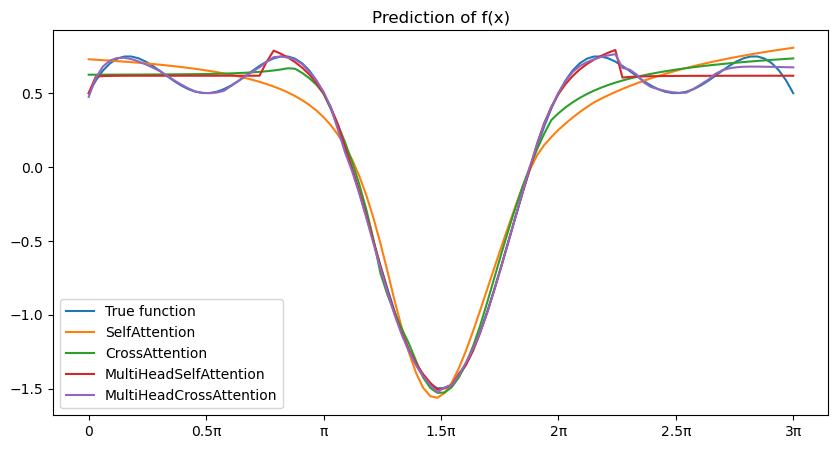

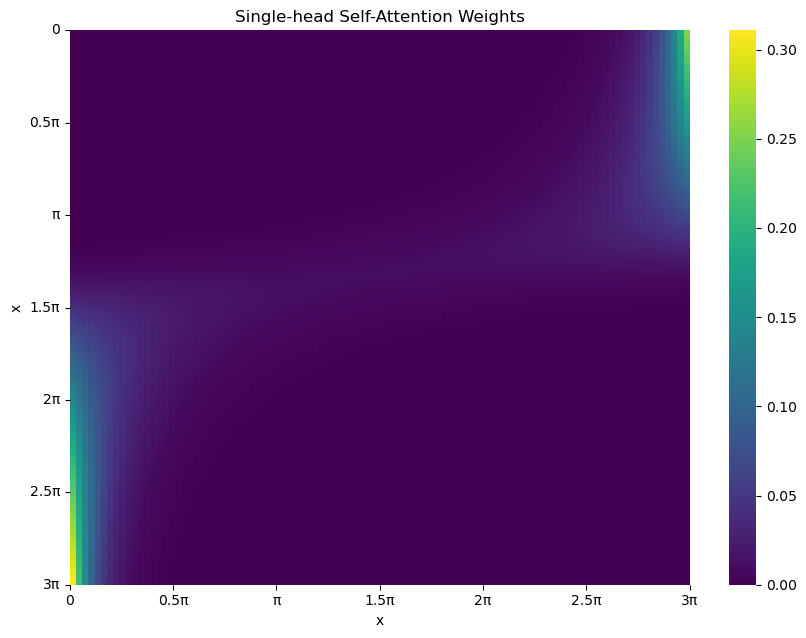

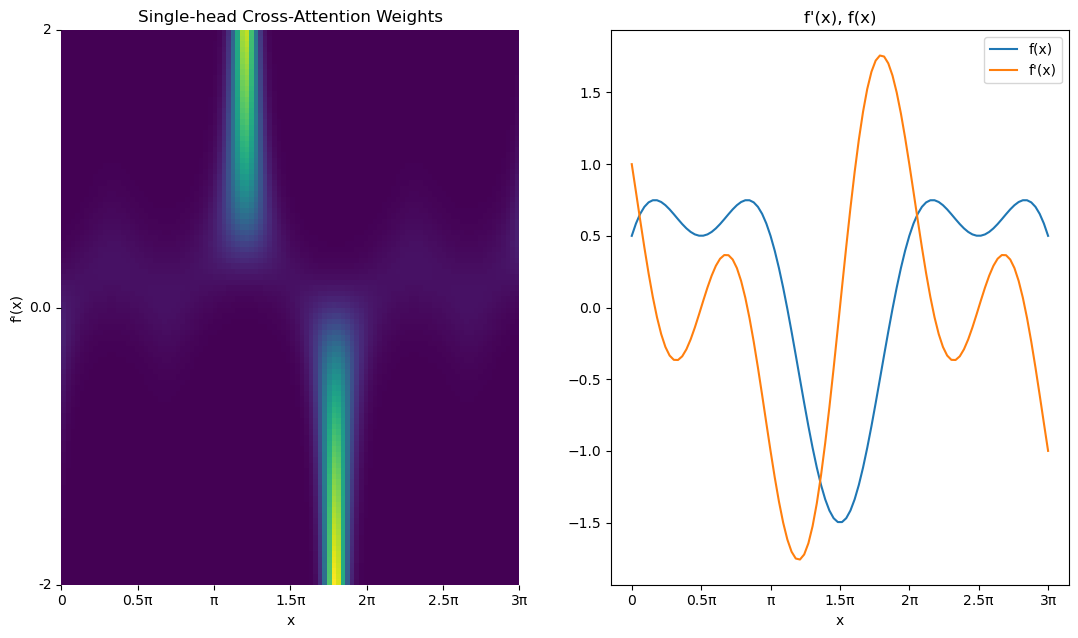

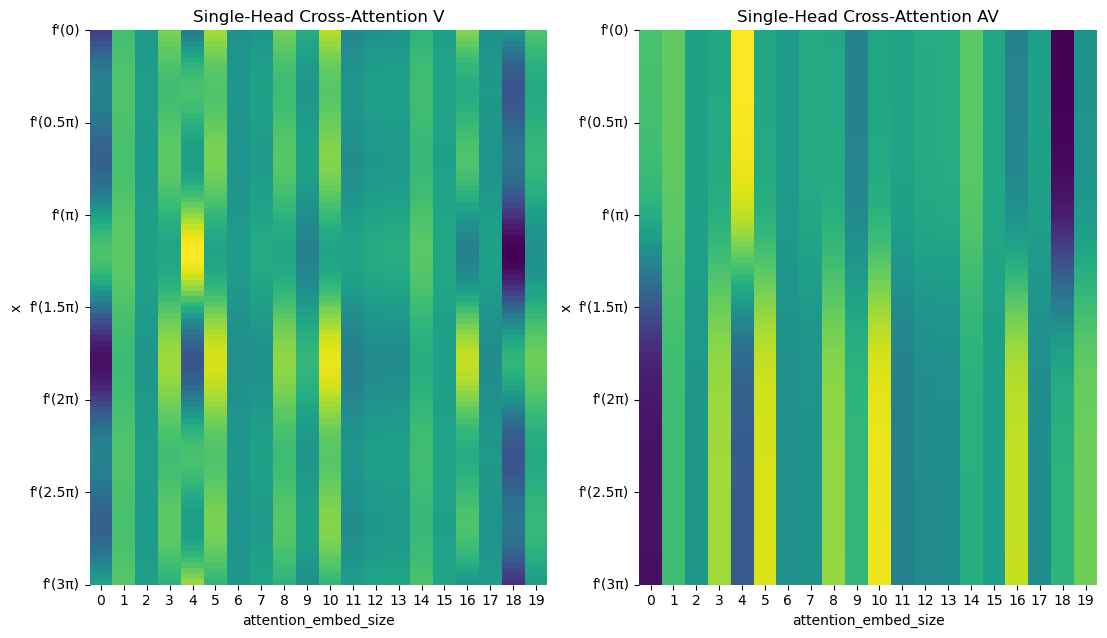

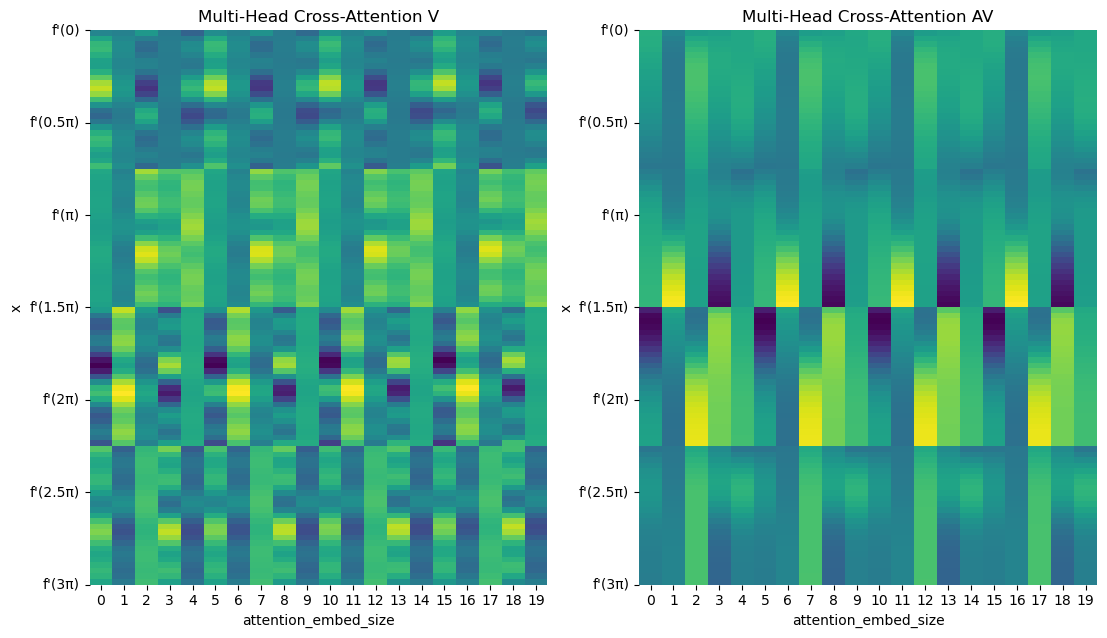

In [4]:
# Testing
def test_attention():
    outputs = {}
    with torch.no_grad():
        for m in models.keys():
            print(f"Testing: {m}")
            models[m].eval()
            outputs[m] = {}
            x_input = x_tensor.view(1, -1, 1)
            if m in CROSS_MODELS:
                yd_input = yd_tensor.view(1, -1, 1)
                preds, A, V, Z = models[m](x_input, yd_input)
            else:
                preds, A, V, Z = models[m](x_input)
            preds = preds.view(-1)
            outputs[m]['preds'] = preds
            outputs[m]['A'] = A
            outputs[m]['V'] = V
            outputs[m]['Z'] = Z
    return outputs

outputs = test_attention()
print("Done testing")

def plot_predicted_actual():
    #Plot predicted f(x) vs actual F(x)
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.plot(x, y, label='True function')
    for m in outputs.keys():
        #break
        #print("sdkh")
        #print(f"outputs[m]['preds'].numpy(): {outputs[m]['preds'].numpy().shape}")
        ax.plot(x, outputs[m]['preds'].numpy(), label=m)
    ax.set_title("Prediction of f(x)")
    ax.set_xticks(np.linspace(0, 3*math.pi, 7), ["0","0.5π", "π", "1.5π", "2π", "2.5π", "3π"])
    ax.legend()

def plot_single_head_self_attention_weights(A):
    #Plot single head self-attention weights
    fig1, ax1 = plt.subplots(1, 1, figsize=(10, 7.2))
    sns.heatmap(A[0].detach().numpy(), cmap='viridis', cbar=True)
    ax1.set_title('Single-head Self-Attention Weights')
    ax1.set_xlabel('x')
    ax1.set_ylabel('x')
    ax1.set_xticks(np.linspace(0, SEQUENCE_LENGTH, 7), ["0","0.5π", "π", "1.5π", "2π", "2.5π", "3π"])
    ax1.set_yticks(np.linspace(0, SEQUENCE_LENGTH, 7), ["0","0.5π", "π", "1.5π", "2π", "2.5π", "3π"])
    
def plot_single_head_cross_attention_weights(A):
    #Plot single-head cross-attention weights + f'(x)
    fig2, (ax21,ax22) = plt.subplots(1, 2, figsize=(13, 7.2))
    sns.heatmap(A[0].detach().numpy(), cmap='viridis', cbar=False, ax=ax21)
    ax21.set_title('Single-head Cross-Attention Weights')
    ax21.set_ylabel("f'(x)")
    ax21.set_xlabel('x')

    ax21.set_yticks(np.linspace(0, SEQUENCE_LENGTH, 3))
    ax21.set_yticklabels([str(round(min(yd))),str(0.0),str(round(max(yd)))][::-1])

    ax21.set_xticks(np.linspace(0, SEQUENCE_LENGTH, 7), ["0","0.5π", "π", "1.5π", "2π", "2.5π", "3π"])
    ax22.set_title("f'(x), f(x)")
    ax22.plot(x, y, label="f(x)")
    ax22.plot(x, yd, label="f'(x)")
    ax22.set_xlabel("x")
    ax22.set_xticks(np.linspace(0, 3*math.pi, 7), ["0", "0.5π", "π", "1.5π", "2π", "2.5π", "3π"])
    ax22.legend()

def plot_single_head_cross_attention_VZ(V, Z):
    # Plotting single-head cross attention V and Z=AV
    fig3, (ax31, ax32) = plt.subplots(1, 2, figsize=(13, 7.2))
    sns.heatmap(V[0].detach().numpy(), cmap='viridis', cbar=False, ax=ax31)
    ax31.set_yticks(np.linspace(0, SEQUENCE_LENGTH, 7), ["f'(0)","f'(0.5π)", "f'(π)", "f'(1.5π)", "f'(2π)", "f'(2.5π)", "f'(3π)"])
    sns.heatmap(Z[0].detach().numpy(), cmap='viridis', cbar=False, ax=ax32)
    ax32.set_yticks(np.linspace(0, SEQUENCE_LENGTH, 7), ["f'(0)","f'(0.5π)", "f'(π)", "f'(1.5π)", "f'(2π)", "f'(2.5π)", "f'(3π)"])
    ax31.set_title('Single-Head Cross-Attention V')
    ax32.set_title('Single-Head Cross-Attention AV')
    ax31.set_xlabel('attention_embed_size')
    ax32.set_xlabel('attention_embed_size')
    ax31.set_ylabel('x')
    ax32.set_ylabel('x')

def plot_multi_head_cross_attention_VZ(V, Z):
    # Plotting multi-head cross attention V and Z=AV
    fig4, (ax41,ax42) = plt.subplots(1, 2, figsize=(13, 7.2))
    sns.heatmap(V.reshape(SEQUENCE_LENGTH, ATTENTION_EMBED_SIZE).detach().numpy(), cmap='viridis', cbar=False, ax=ax41)
    ax41.set_yticks(np.linspace(0, SEQUENCE_LENGTH, 7), ["f'(0)","f'(0.5π)", "f'(π)", "f'(1.5π)", "f'(2π)", "f'(2.5π)", "f'(3π)"])
    sns.heatmap(Z[0].detach().numpy(), cmap='viridis', cbar=False, ax=ax42)
    ax42.set_yticks(np.linspace(0, SEQUENCE_LENGTH, 7), ["f'(0)","f'(0.5π)", "f'(π)", "f'(1.5π)", "f'(2π)", "f'(2.5π)", "f'(3π)"])
    ax41.set_title('Multi-Head Cross-Attention V')
    ax42.set_title('Multi-Head Cross-Attention AV')
    ax41.set_xlabel('attention_embed_size')
    ax42.set_xlabel('attention_embed_size')
    ax41.set_ylabel('x')
    ax42.set_ylabel('x')
    
    
plot_predicted_actual()
plot_single_head_self_attention_weights(outputs['SelfAttention']['A'])
plot_single_head_cross_attention_weights(outputs['CrossAttention']['A'])
plot_single_head_cross_attention_VZ(outputs['CrossAttention']['V'], outputs['CrossAttention']['Z'])
plot_multi_head_cross_attention_VZ(outputs['MultiHeadCrossAttention']['V'], outputs['MultiHeadCrossAttention']['Z'])

# Transformers

Transformers are neural networks that process sequence data by adopting a fully attention based approach. This allows for parallelization - faster training and inference. Attention also allows for much larger contexts than recurrence, meaning transformers could generate output embeddings that more accurately capture contextual semantics.


## Transformer Architecture 

The **Encoder** uses self-attention to produce contextual representation of the input sequence.

The **Decoder** outputs token embeddings of the predicted sequence. It applies self-attention to the autoregressive predictions and then cross-attention to decoder's current hidden states (produces Q) and the Encoder outputs (produces K,V).

The **Projector** projects outputs from embedding space, attempting to produce logits over tokens in our vocabulary.

The Encoder and Decoder have a final **Feed Forward** sub-layer which typically involves 2 MLPs followed by a ReLU activation function.

Every sub-layer in the Encoder and Decoder (e.g attention, feed-forward) is wrapped in an **Add & Norm (Residual Connection)** block.This involves a residual connection to add the input of a sub-layer to its output and then normalization to stabilize the training process. 
$$AddNorm(X,Sublayer(X)) = LayerNorm(X + Sublayer(X))$$

<p style="text-align:center;">The original Transformer Architecture from Attention is All You Need</p>
<img src="transformer.jpg" width="800" align="center">

## Transformer-based LLMs
Suppose our Transformer is a causal LLM, which is a type of autoregressive model that predicts the next token in a sequence based solely on the tokens that came before it + encoded input. It is attempting to learn weights that will express $\hat{Y} = f(X)$, an estimate of the unknown function $Y = F(X)$. This model is working with sequential data in the form:
$$X = [x_1, x_2, ..., x_n]$$
$$Y = [y_1, y_2, ..., y_m]$$

Where $x_i$ and $y_i$ denote encoded token integers. When building your dataset, you would include the \<eos\> token explicitly at the end of the target sequence $Y$.

### Forward Pass at Test Time Using Greedy Decoding

The following pseudo-code demonstrates one way a transformer-based LLMs may perform a forward pass throught the network at test time. The Decoder is directly responsible for predicting $m$ tokens from $n$ input tokens in an auto-regressive fashion. We are demonstrating the Greedy Decoding algorithm. Each iteration the Decoder uses $[sos, \hat{y}_1,...,\hat{y}_{i-1}]$ to predict $[\hat{y}_1, ..., \hat{y}_i]$, but we only keep $\hat{y}_i$. 

<strong>`f(X)`</strong>: $X \in \mathbb{Z_+}^n$
> `X_embedded = InputEmbedding(X) + PositionalEncoding(X)` shape: $n \times d_{model}$  
> `X_encoded = Encoder(X_embedded)` shape: $n \times d_{model}$  
> `Y = []` stores predicted tokens  
> `Y_embedded = [OutputEmbedding(SOS_TOKEN)]` stores predicted token embeddings    
> <strong>`WHILE`</strong> `len(Y_embedded) < max_sequence_len` <strong>`AND`</strong> `Y[-1] != EOS_TOKEN:`  
>> `Y_decoded = Decoder(Y_embedded, X_encoded)` shape: $len(Y\_embedded) \times d_{model}$  
>> `y_i_logits = Projector(Y_decoded[-1])` shape: $\text{vocabulary size}$  
>> `y_i_token = argmax(y_i_logits)` this is a single integer  
>> `Y = Concat(Y, y_i_token)`  
>> `y_i_embedded = OutputEmbedding(y_i_token) + PositionalEncoding(y_i_token)` $Y_{i_{embedded}} \in \mathbb{R}^{1 \times d_{model}}$  
>> `Y_embedded = Concat(Y_embedded, y_i_embedded)`

> <strong>`return`</strong> `Y`

Modern LLMs use beam search or sampling-based methods like top-k, nucleus/top-p sampling, temperature scaling.

Recall our attention formula: 
$$Z = Attention(Q, K, V) = AV = softmax\left(\frac{QK^T}{\sqrt{d_{model}}}\right)V$$

###### Encoder Forward Pass
The encoder applies Multi-Head Self-Attention and Feed Forward (each wrapped Add&Norm) on `X_embedded` to produce `X_encoded` which we will denote as: $$Z_X \in \mathbb{R}^{n \times d_{model}}$$. The input passes through $N_B$ of these encoder blocks sequentially. The blocks have  the same structure, but different learnable parameters.

$Z_X$ is a contextually-aware embedding of the entire input sequence.

###### Decoder Forward Pass
Iteration $i$ of the Decoder applies Multi-Head Self-Attention (wrapped in Add&Norm) on `Y_embedded` to produce: $$Z_Y \in \mathbb{R}^{i \times d_{model}}$$.

In the same interation the decoder performs Multi-Head Cross-Attention with the following configuration:
$$Q = Z_Y W^Q \text{, so } Q \in \mathbb{R}^{i \times d_{model}}$$
$$K = Z_X W^K \text{, so } K \in \mathbb{R}^{n \times d_{model}}$$ 
$$V = Z_X W^V \text{, so } V \in \mathbb{R}^{n \times d_{model}}$$ 

Since $QK^T, A \in \mathbb{R}^{i \times n}$ the cross-attention output is therefore:
$$Z \in \mathbb{R}^{i \times d_{model}}$$

Cross-Attention with encoder outputs $Z_X$ allows the decoder to focus on different parts of the input sequence $X$ based on the current decoding context $Z_Y$.  

The fully connected layer produces the same shape for final input `Y_decoded`$\in \mathbb{R}^{i \times d_{model}}$.

In the same iteration, the decoder input is passed through $M_B$ of these decoder blocks sequentially.

###### Projector Forward Pass

The projector transforms word embeddings into logit vectors $\hat{Y}_L \in \mathbb{R}^{i \times \text{vocabulary size}}$. After softmax is applied to logits, each vector repesent a probability distribution over all tokens in the vocabulary and can be compared with the respective one-hot encoded labels to compute model loss.

<p style="text-align:center;">One-hot encoded words in a very small vocabulary of length 8</p>
<img src="one_hot_encode_vocab.png" width="300" align="center">

##### Greedy Decoding - Worked Example

Suppose we trained a transformer to perform english to french translation. For brevity we will ignore all concept of tokenization and embedding in this example. We will also assume that $N_B=M_B=1$, i.e there is only one Encoder and Decoder block. We're using the transformer to translate "good luck translator" to "bonne chance traducteur".

1. Encoder produces encoded english sentence $$\text{X_encoded} = [\vec{\text{good}}, \vec{\text{luck}},\vec{ \text{translator}}] = Encoder([\text{good}, \text{luck},\text{translator}])$$

2. Decoder predicts 1st french word $\hat{\text{bonne}}$ from input $[\text{<sos>}]$ and $\text{X_encoded}$. 

The decoder self attention weights look like:

<table border="1">
    <tr>
        <th></th>
        <th align="center">sos</th>
    </tr>
    <tr>
        <th align="center">sos</th>
        <td align="center">sa11</td>
    </tr>
</table>

The decoder cross attention weights look like:

<table border="1">
    <tr>
        <th></th>
        <th align="center">good</th>
        <th align="center">luck</th>
        <th align="center">translator</th>
    </tr>
    <tr>
        <th align="center">sos</th>
        <td align="center">ca11</td>
        <td align="center">ca12</td>
        <td align="center">ca13</td>
    </tr>
</table>

3. Decoder predicts 1st and 2nd french words $\hat{\text{bonne'}}, \hat{\text{chance}}$ from input $[\text{<sos>}, \hat{\text{bonne}}]$ and $\text{X_encoded}$. We discard our repeated prediction $\hat{\text{bonne'}}$.

The decoder self attention weights look like:

<table border="1">
    <tr>
        <th></th>
        <th align="center">sos</th>
        <th align="center">bonne</th>
    </tr>
    <tr>
        <th align="center">sos</th>
        <td align="center">sa11</td>
        <td align="center">sa12</td>
    </tr>
    <tr>
        <th align="center">bonne</th>
        <td align="center">sa21</td>
        <td align="center">sa22</td>
    </tr>
</table>

The decoder cross attention weights look like:

<table border="1">
    <tr>
        <th></th>
        <th align="center">good</th>
        <th align="center">luck</th>
        <th align="center">translator</th>
    </tr>
    <tr>
        <th align="center">sos</th>
        <td align="center">ca11</td>
        <td align="center">ca12</td>
        <td align="center">ca13</td>
    </tr>
    <tr>
        <th align="center">bonne</th>
        <td align="center">ca21</td>
        <td align="center">ca22</td>
        <td align="center">ca23</td>
    </tr>
</table>

4. Decoder predicts 1st, 2nd and 3rd french word $\hat{\text{bonne''}}, \hat{\text{chance'}}, \hat{\text{traducteur}}$ from input $[\text{<sos>}, \hat{\text{bonne}}, \hat{\text{chance}}]$ and $\text{X\_encoded}$. We discard our repeated predictions $\hat{\text{bonne''}}$ and $\hat{\text{chance'}}$.

The decoder self attention weights look like:

<table border="1">
    <tr>
        <th></th>
        <th align="center">sos</th>
        <th align="center">bonne</th>
        <th align="center">chance</th>
    </tr>
    <tr>
        <th align="center">sos</th>
        <td align="center">sa11</td>
        <td align="center">sa12</td>
        <td align="center">sa13</td>
    </tr>
    <tr>
        <th align="center">bonne</th>
        <td align="center">sa21</td>
        <td align="center">sa22</td>
        <td align="center">sa23</td>
    </tr>
    <tr>
        <th align="center">chance</th>
        <td align="center">sa31</td>
        <td align="center">sa32</td>
        <td align="center">sa33</td>
    </tr>
</table>

The decoder cross attention weights look like:

<table border="1">
    <tr>
        <th></th>
        <th align="center">good</th>
        <th align="center">luck</th>
        <th align="center">translator</th>
    </tr>
    <tr>
        <th align="center">sos</th>
        <td align="center">ca11</td>
        <td align="center">ca12</td>
        <td align="center">ca13</td>
    </tr>
    <tr>
        <th align="center">bonne</th>
        <td align="center">ca21</td>
        <td align="center">ca22</td>
        <td align="center">ca23</td>
    </tr>
    <tr>
        <th align="center">chance</th>
        <td align="center">ca31</td>
        <td align="center">ca32</td>
        <td align="center">ca33</td>
    </tr>
</table>

Official output: $\hat{\text{bonne}}, \hat{\text{chance}}, \hat{\text{traducteur}}$

For each iteration, only the most recent word prediction is appended to the growing sequence.

## Transformer Training - Teacher Forcing
When training the Transformer it is possible to follow the same Greedy Decoding process that was applied at test time - for each iteration $i$ we calculate the loss between $[\hat{y}_1,...,\hat{y}_{i+1}]$ and $[y_1, ..., y_{i+1}]$ given input $\text{X_encoded}$ and $[<sos>, y_1, ..., y_{i}]$. But this is inefficient and it's not necessary to use prior token predictions to predict future tokens since all of the true target tokens are already available to us. Using true targets  


Teacher Forcing with masking simulates the auto-regressive behavior in one single forward pass. This involves inputting $[<sos>, y_1, ..., y_{m-1}]$ into the Decoder and apply a masking technique which prevents the model from 'cheating' by blocking leftward information flow in the Self-Attention matrix (pre-softmax). 
    
    
<table border="1">
    <tr>
        <th></th>
        <th align="center">sos</th>
        <th align="center">bonne</th>
        <th align="center">chance</th>
    </tr>
    <tr>
        <th align="center">sos</th>
        <td align="center">sa11</td>
        <td align="center">-∞</td>
        <td align="center">-∞</td>
    </tr>
    <tr>
        <th align="center">bonne</th>
        <td align="center">sa21</td>
        <td align="center">sa22</td>
        <td align="center">-∞</td>
    </tr>
    <tr>
        <th align="center">chance</th>
        <td align="center">sa31</td>
        <td align="center">sa32</td>
        <td align="center">sa33</td>
    </tr>
</table>
    
The masking operation transforms the self attention matrix into a lower triangular matrix where the upper terms past the diagonal are set to $-\infty$. This prevents current tokens from attending to future tokens. In other words, token $i$ can't see tokens $i+1, i+2,...$. The diagonal of the matrix usually includes the token’s ability to attend to itself, and everything below the diagonal is what’s “in the past.”

Note: In an encoder-decoder architecture for, say, translation, you typically also keep a separate “encoder-decoder attention” (cross-attention) that is not masked (the decoder can attend freely to all encoder outputs). The only place the strict left-to-right mask is applied is in the decoder’s self-attention sub-layer.

## Transformer Loss

Categorical Cross-entropy Loss the most popular loss function for LLMs trained to generate text. 

Recall that the Projector passes the decoder output `Y_decoded`$\in \mathbb{R}^{m \times d_{model}}$ through a linear layer and a softmax activation function. The linear layer generates logits with shape $m \times \text{vocabulary size}$. when passed through the softmax function the final output of the transformer is a sequence of probability vectors $\hat{P} = [p_1, ..., p_m]$ where $p_i$ has $\text{vocabulary size}$ dimensions. This probability vector represents a distribution over all words in the vocabulary, indicating the likelihood of a specific word appearing.

We train the Transformer to minimize the following loss function:
$$\text{Categorical Cross-Entropy Loss}$$
$$L = -\frac{1}{m}\sum_{i}^{m} p(y_i)log(\hat{p}_i)$$

Where $p(y_i)$ is the one-hot encoding of the token $y_i$

A lower cross-entropy loss function indicates that the model is better at matching the vocabulary-wide distribution of the predicted word with that of the true word.

### Further Reading:

GPT Interactive Visualization:
https://bbycroft.net/llm

The Transformer Explained
https://poloclub.github.io/transformer-explainer/

The illustrated transformer:
https://jalammar.github.io/illustrated-transformer/

The annotated transformer (transformer implemented from scratch using PyTorch):
https://nlp.seas.harvard.edu/annotated-transformer/

## Hugging Face

Hugging Face Hub is a repository of resources for machine learning, including pre-trained models.

Hugging Face's `transformers` library is a Python library that provides a unified interface for working with transformer models. It provides a wide range of models like GPT, BERT, T5 and Llama as well as their pre-trained weights. The library is built on top of `PyTorch` and `TensorFlow`, allowing users to choose their preferred backend. 

While `PyTorch` expects you to manually define and integrate layers, `transformers` provides high-level abstractions that encapsulate common patterns. This reduces the amount of repetitive boilerplate code you need to write.

### Key Components in `transformers`

* All pre-trained model/tokenizer checkpoints are identified by a model ID string (e.g `'bert-base-uncased'`, `'gpt2'`)
* Classes prefixed by `Auto*` are factory classes that automatically select and load the appropriate tokenizer or model class based on the provided model ID.
* `AutoTokenizer` loads the tokenizer configuration, including the vocabulary.
* Commonly used `Tokeinzer` methods:
    * `from_pretrained`: Loads tokenizer configuration and vocabulary from a pre-trained model repository or local directory.
    * `save_pretrained`: Saves the tokenizer’s configuration and vocabulary files to a directory, which can then be reloaded using from_pretrained.
    * `encode`: Converts a text string into a sequence of token IDs, applying all the necessary tokenization steps (padding, truncation, add special tokens, etc.).
    * `decode`: Converts a list of token IDs back to a string, removing any special tokens and handling subword tokens correctly.
* `AutoModel` loads only the core Transformer backbone which outputs the raw hidden representations/embeddings. The model will not include any task-specific head (projector) such as those used to convert embeddings to token ID distributions. Useful if you wish to build additional functionality ontop of a pre-trained model.
* Commonly used `Model` methods:
    * `from_pretrained`: Similar to tokenizers, this method loads a model with pre-trained weights from the specified directory or model ID from Hugging Face's model hub.
    * `save_pretrained`: Saves the model’s weights and configuration to a directory for later use or deployment.
    * `forward`: Implements the model's forward pass logic. This method is called during training and inference and must be implemented by all subclasses.
* Classes prefixed by `AutoModelFor*` load the base model along with extra, task-specific layers (heads) that tailor the outputs for a particular application:
    *  `AutoModelForCausalLM` loads a model with heads designed for auto-regressive language modeling (e.g., text generation). This wraps the transformer with a head that maps hidden states to vocabulary scores, enabling next-token prediction.
    * `AutoModelForSequenceClassification` loads a model variant with heads tailored for classification tasks (like sentiment analysis or spam detection). It adds a classification head on top of the transformer.
    * https://huggingface.co/docs/transformers/model_doc/auto ctrl f "AutoModelFor" to see other variants.

In [1]:
from transformers import AutoModel, AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification

# Automatically loads the appropriate GPT-2 model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")
model_base = AutoModel.from_pretrained("gpt2")
model_causal = AutoModelForCausalLM.from_pretrained("gpt2")
model_sentiment = AutoModelForSequenceClassification.from_pretrained("riturajpandey739/gpt2-sentiment-analysis-tweets")


C:\Users\z5162987\anaconda3\envs\vip_tuts\lib\site-packages\huggingface_hub\file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\z5162987\anaconda3\envs\vip_tuts\lib\site-packages\huggingface_hub\file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


### Generative Pre-trained Transformer (GPT)

All GPT Transformers only involve a Decoder, which receives the entire input sequence (prompt) at once and generates the output sequence (response) autoregressively. For every iteration the Decoder input becomes the concatenation of the original prompt and the (response) tokens produced so far. The Decoder then uses Self-Attention over the entire sequence (subject to causal masking during training) to predict the next token. The model does not contain any Cross-Attention layers, it only involves causal Self-Attention. 

Hugging Face model card: https://huggingface.co/openai-community/gpt2

Interactive visualization of GPT models: https://bbycroft.net/llm

<p style="text-align:center;">GPT2</p>
<img src="gpt2.png" width="500" align="center">

In [18]:
print(model_base)

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D()
        (c_proj): Conv1D()
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D()
        (c_proj): Conv1D()
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [19]:
print(model_causal)
#lm_head project output embeddings to tokens

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [38]:
print(model_sentiment)

GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=768, out_features=3, bias=False)
)


* When a PyTorch backend is used the `transformers` models subclasses from `torch.nn.Module` and inherits all the same functions and attributes.

In [2]:
total_model_params = 0
for name, module in model_causal.named_modules():
    params = list(module.parameters(recurse=False))
    if params:
        shapes = [p.shape for p in params]
        component_param_total = sum(p.numel() for p in params)
        total_model_params += component_param_total
        print(f"Component: {name}")
        print("Parameter shapes:", shapes)
        print("Total parameters in this component:", component_param_total)
        print("=" * 40)
print(f"Total number of parameters: {total_model_params}")

Component: transformer.wte
Parameter shapes: [torch.Size([50257, 768])]
Total parameters in this component: 38597376
Component: transformer.wpe
Parameter shapes: [torch.Size([1024, 768])]
Total parameters in this component: 786432
Component: transformer.h.0.ln_1
Parameter shapes: [torch.Size([768]), torch.Size([768])]
Total parameters in this component: 1536
Component: transformer.h.0.attn.c_attn
Parameter shapes: [torch.Size([768, 2304]), torch.Size([2304])]
Total parameters in this component: 1771776
Component: transformer.h.0.attn.c_proj
Parameter shapes: [torch.Size([768, 768]), torch.Size([768])]
Total parameters in this component: 590592
Component: transformer.h.0.ln_2
Parameter shapes: [torch.Size([768]), torch.Size([768])]
Total parameters in this component: 1536
Component: transformer.h.0.mlp.c_fc
Parameter shapes: [torch.Size([768, 3072]), torch.Size([3072])]
Total parameters in this component: 2362368
Component: transformer.h.0.mlp.c_proj
Parameter shapes: [torch.Size([3072,

In [3]:
print(model_causal.config)

GPT2Config {
  "_name_or_path": "gpt2",
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "transformers_version": "4.32.1",
  "use_cache": true,
  "vocab_size": 50257
}



* `generate` is a high-level function designed for sequence generation tasks (e.g., text generation, completion). It implements various decoding strategies internally—such as greedy search, beam search, top‑k/top‑p sampling, etc.—to iteratively generate tokens until a stopping criterion is reached (like an end-of-sequence token or a maximum length).
* `.forward` is the default method for models in the  `transformers` library which is executed when the model object is called like a function. It is a low-level function which implements the model's forward pass logic, outputting either raw logits or hidden states. It doesn't perform any generation or iterative decoding.

In [59]:
def generate_text(prompt, model, tokenizer, num_beams=5, no_repeat_ngram_size=2, top_p=0.1, temperature=0.3):
    inputs = tokenizer.encode(prompt, return_tensors="pt")
    # return_tensors="pt" wraps the list into a PyTorch tensor
    outputs = model.generate(
        input_ids=inputs,     # The input prompt as token IDs
        max_length=100,      # Maximum length (in tokens) for the generated sequence
        num_return_sequences=1,     # Number of generated sequences to return
        pad_token_id=tokenizer.pad_token_id,     # ID used for padding; if input is shorter than max_length
        bos_token_id=tokenizer.bos_token_id,     # Beginning-of-sequence token ID
        eos_token_id=tokenizer.eos_token_id,     # End-of-sequence token ID; generation stops if this token is produced
        num_beams=num_beams,     
        no_repeat_ngram_size=no_repeat_ngram_size,      
        top_p=top_p, 
        early_stopping=True, 
        temperature=temperature     # Controls randomness in predictions by scaling logits: lower temperature makes output more deterministic
    )
    # skip_special_tokens=True removes tokens like <eos>, <bos>, or <pad> from the output
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


def generate_logits(prompt, model, tokenizer):
    inputs = tokenizer.encode(prompt, return_tensors="pt")
    outputs = model(inputs)
    return outputs.logits

in_prompt = "Hello what is your name?"
out_text = generate_text(in_prompt, model_causal, tokenizer)
out_logits = generate_logits(in_prompt, model_causal, tokenizer)
print(f"Text Response: {out_text}")
print(f"Logits Response: {out_logits.shape}")


C:\Users\z5162987\anaconda3\envs\vip_tuts\lib\site-packages\transformers\generation\configuration_utils.py:362: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.3` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
C:\Users\z5162987\anaconda3\envs\vip_tuts\lib\site-packages\transformers\generation\configuration_utils.py:367: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Text Response: Hello what is your name?

My name is John. I'm a man who has been living in the United States since I was a little boy. My father was born in New York City, and my mother is from New Jersey, so I've been here for a long time. So when I got here, I didn't know what to do with my life, but I knew I wanted to go to college. And then I went to the University of California, where I majored
Logits Response: torch.Size([1, 6, 50257])


* The `pipeline` function is used to perform different tasks with pre-trained models, creating the model and tokenizer, loading them with pre-trained weights and providing a function you can use to run the specified task. 

In [62]:
from transformers import pipeline

#https://huggingface.co/riturajpandey739/gpt2-sentiment-analysis-tweets
classifier = pipeline("text-classification", model="riturajpandey739/gpt2-sentiment-analysis-tweets")
'''
Negative: Label 0
Neutral: Label 1
Positive: Label 2
'''
text = "This product is amazing! I absolutely love it."
result = classifier(text)
print(text)
print(f"result: {result}")

text = "The product stopped working. It is bad."
result = classifier(text)
print(text)
print(f"result: {result}")

text = "I love to hate people."
result = classifier(text)
print(text)
print(f"result: {result}")

This product is amazing! I absolutely love it.
result: [{'label': 'LABEL_2', 'score': 0.9976001381874084}]
Microsoft is the worst company on Earth.
result: [{'label': 'LABEL_0', 'score': 0.9855802655220032}]
I love to hate people.
result: [{'label': 'LABEL_2', 'score': 0.9324226975440979}]


## Chatbots

When building chatbots or dialogue systems, it’s not enough to generate an isolated response. The system must remember previous inputs and responses to maintain context over multiple turns. The `Conversation` class holds the dialogue history and manages multi-turn conversational context. Each time the `Conversation` object receives a new prompt (via initialization or through methods like `add_user_input()`), it appends this input to the conversation history. At each turn of the conversation we input the entire conversation history. 

The `Conversation` class is primarily meant for use with models that have been fine-tuned on conversational data (like BlenderBot, not like GPT2). These models know how to interpret the multi-turn context that the Conversation object provides.

In [5]:
import time
from transformers import pipeline, Conversation

# Create pipelines using the "conversational" pipeline for both models.
#chatbot1 = pipeline("conversational", model="microsoft/DialoGPT-medium")
chatbot1 = pipeline("conversational", model="facebook/blenderbot-400M-distill")
chatbot2 = pipeline("conversational", model="facebook/blenderbot-400M-distill")

# Set the number of conversation iterations.
num_iterations = 5

# Initialize the conversation with a starting prompt.
initial_prompt = "Hello! How are you today?"
conv = Conversation(initial_prompt)

print("Starting conversation:")
print("=" * 40)
print(f"Initial prompt: {initial_prompt}")
print("=" * 40)
print()

# Use the same Conversation object for both chatbots.
for i in range(num_iterations):
    # Chatbot 1 (DialoGPT) responds first.
    result1 = chatbot1(conv)
    # The conversation object now contains an updated history.
    response1 = result1.generated_responses[-1]
    print(f"Turn {i * 2 + 1} (Blenderbot-400M 1):")
    print(response1)
    print("-" * 40)
    time.sleep(1)
    conv.add_user_input(response1)
    # Chatbot 2 (BlenderBot) now responds.
    result2 = chatbot2(conv)
    response2 = result2.generated_responses[-1]
    print(f"Turn {i * 2 + 2} (Blenderbot-400M 2):")
    print(response2)
    print("=" * 40)
    conv.add_user_input(response2)
    time.sleep(1)

print("Conversation ended.")


Starting conversation:
Initial prompt: Hello! How are you today?

Turn 1 (Blenderbot-400M 1):
 I'm doing well, thank you. How about yourself? Do you have any plans for the weekend?
----------------------------------------


Conversation input is to long (55), trimming it to (60 - 10)


Turn 2 (Blenderbot-400M 2):
 I do! I'm going to a concert with some friends. I'm looking forward to it. 


Conversation input is to long (104), trimming it to (60 - 10)


Turn 3 (Blenderbot-400M 1):
 What concert are you going to? I love going to concerts with my friends.
----------------------------------------


...

Turn 8 (Blenderbot-400M 2):
 Yes it is. They are also one of the most successful bands of all time. 


Trimmed input from conversation as it was longer than 128 tokens.
Conversation input is to long (128), trimming it to (60 - 10)


Turn 9 (Blenderbot-400M 1):
 Yes they are. They were formed in 1985 in Los Angeles, California.
----------------------------------------


Trimmed input from conversation as it was longer than 128 tokens.
Conversation input is to long (128), trimming it to (60 - 10)


Turn 10 (Blenderbot-400M 2):
 Yes, and they are one of the most successful bands in the history of rock and roll. 
Conversation ended.


## Fine Tuning LLMs

In the next code example we will perform fine tuning on a pre-trained version of GPT2 using an article about the history of Australia in the Olympics: https://www.olympics.com.au/100-years-of-the-aoc/. 

**Fine tuning** involves resuming the training process of a pre-trained model using unseen data. Typically fine tuning is performed with fewer training epochs and lower learning rates.

In [6]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

#tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
#model = GPT2LMHeadModel.from_pretrained("gpt2")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")

#tokenizer = AutoTokenizer.from_pretrained("facebook/blenderbot-400M-distill")
#model = AutoModelForSeq2SeqLM.from_pretrained("facebook/blenderbot-400M-distill")

#"gpt2": The base model.
#"gpt2-medium": A medium-sized model with more layers and parameters.
#"gpt2-large": A larger version with even more capacity.
#"gpt2-xl": The largest available GPT-2 model with the highest number of parameters for more complex tasks.

def generate_text(prompt, model, tokenizer, num_beams=5, no_repeat_ngram_size=2, top_p=0.1, temperature=0.3):
    inputs = tokenizer.encode(prompt, return_tensors="pt")
    inputs_ = inputs.to('cpu')
    model_ = model.to('cpu')
    outputs = model_.generate(inputs_, max_length=100, num_beams=num_beams, no_repeat_ngram_size=no_repeat_ngram_size, top_p=top_p, early_stopping=True, temperature=temperature)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

prompt = "A transformer is a "
response = generate_text(prompt, model, tokenizer)
print("Response:", response)

# Example query before fine-tuning
prompt = "Jessica Fox won gold in "
response = generate_text(prompt, model, tokenizer, num_beams=10, no_repeat_ngram_size=4, top_p=0.4, temperature=0.8)
print("\n\nResponse:", response)
prompt = "Who is Cathy Freeman?"
response = generate_text(prompt, model, tokenizer, num_beams=10, no_repeat_ngram_size=4, top_p=0.4, temperature=0.8)
print("\n\nResponse:", response)
prompt = "In Tokyo 2020, Emma McKeon "
response = generate_text(prompt, model, tokenizer, num_beams=10, no_repeat_ngram_size=4, top_p=0.4, temperature=0.8)
print("\n\nResponse:", response)
prompt = "Patrick Mills is a"
response = generate_text(prompt, model, tokenizer, num_beams=10, no_repeat_ngram_size=4, top_p=0.4, temperature=0.8)
print("\n\nResponse:", response)
prompt = "Australia's Olympic history is "
response = generate_text(prompt, model, tokenizer, num_beams=10, no_repeat_ngram_size=4, top_p=0.4, temperature=0.8)
print("\n\nResponse:", response)

C:\Users\z5162987\anaconda3\envs\vip_tuts\lib\site-packages\transformers\generation\configuration_utils.py:362: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.3` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
C:\Users\z5162987\anaconda3\envs\vip_tuts\lib\site-packages\transformers\generation\configuration_utils.py:367: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
C:\Users\z5162987\anaconda3\envs\vip_tuts\lib\site-packages\transformers\generation\configuration_utils.p

Response: A transformer is a vernacular term used to describe a transformer that is connected to a power source, such as a generator or power plant.

The term transformer refers to any type of transformer, including, but not limited to, transformers that are used in the production of electricity, power plants, or other sources of power. The term is also used interchangeably with the term "transformer" in a number of other contexts. For example, "a transformer" may refer to an


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.




Response: Jessica Fox won gold in vernacular.

"I don't think I've ever seen anything like it," he said. "I've never seen anything like that in my life."


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.




Response: Who is Cathy Freeman?

Cathy Freeman is the founder and editor-in-chief of Feministing.com, a feminist news site. She is the author of several books, including The Feminine Mystique: How Feminism Has Changed the World. She is also the co-author of the new book, Feminism: A Feminist History.

Follow her on Twitter: @CathyFreeman.

This article originally appeared on Feministing.


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.




Response: In Tokyo 2020, Emma McKeon  was the first woman to be elected to the Tokyo City Council.  She was the first woman elected to the city council in Japan.  It was the first time in Japan that a woman had been elected to the council.  Emma McKeon was the first female mayor of Tokyo.  The first woman to run for mayor of Tokyo in a Japanese city.  This is the first time that a woman has been


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.




Response: Patrick Mills is a reporter for Breitbart Tech. You can follow him on Twitter @BreitbartTech, or like his page at Facebook.


Response: Australia's Olympic history is  inextricably linked to that of the United States.  The United States is the only country in the world that has won a gold medal in the Olympic Games.  It is also the only country to have won a silver medal in the Olympics.  In fact, the United States is one of only two countries in the world to have won an Olympic gold medal.  This is the first time that the United States has won an Olympic


**`TextDataset`**  
Facilitates the loading and preprocessing of raw text files for training language models. Handles tokenization, separates text into blocks. Somewhat similar to PyTorch's `datasets` class.

One block makes up one training sample. Each block is treated independently during training. The block size affects how much context the model sees at any one time during training. Blocks don't overlap.

Some `TextDataset` methods:
* `__len__`: returns number of items (blocks or sequences) in the dataset
* `__getitem__`: retrievs a single item from the dataset at a specific index 

Data collators act as a helper tool used within or alongside a DataLoader to perform more complex transformations/preprocessing steps like token masking and padding sequences in the case of **`DataCollatorForLanguageModeling`**

**`TrainingArguments`** class in the Hugging Face Transformers library is used to encapsulate all the hyperparameters and other configuration details that control the training process


**`Trainer`** abstracts away much of the boilerplate training loop necessary for training deep learning models by handling the training loop internally. Under the hood it uses PyTorch DataLoader and the DataCollator correctly formats and batches the data.

In [74]:
from transformers import TextDataset, DataCollatorForLanguageModeling, Trainer, TrainingArguments, LineByLineTextDataset

# Load the dataset and prepare for training
# dataset = TextDataset(
#     tokenizer=tokenizer,
#     file_path="Australian_Olympics_21ct.txt",
#     block_size=100, 
# )

dataset = LineByLineTextDataset(
    tokenizer=tokenizer,
    file_path="Australian_Olympics_21ct.txt",
    block_size=100
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=False
)

training_args = TrainingArguments(
    output_dir="./blenderbot-finetuned", # Directory where model checkpoints will be saved
    overwrite_output_dir=True,
    num_train_epochs=2,
    per_device_train_batch_size=2,
    save_steps=100, # Save a model checkpoint every 100 steps
    save_total_limit=2, # Limit the total amount of checkpoints; deletes older checkpoints
    learning_rate = 0.0001,
)

model = model.to(device)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=dataset
)

# Fine-tuning the model
trainer.train()

C:\Users\z5162987\anaconda3\envs\vip_tuts\lib\site-packages\transformers\data\datasets\language_modeling.py:119: FutureWarning: This dataset will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py
  warnings.warn(
You're using a BlenderbotTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss


KeyboardInterrupt: 

In [70]:
# can also load the model saved during trainer.train():
#model = GPT2LMHeadModel.from_pretrained("./gpt2-finetuned/checkpoint-200")

# Test the fine-tuned model
prompt = "Jessica Fox won gold in "
response = generate_text(prompt, model, tokenizer, num_beams=10, no_repeat_ngram_size=4, top_p=0.4, temperature=0.8)
print("\n\nResponse:", response)
prompt = "Who is Cathy Freeman?"
response = generate_text(prompt, model, tokenizer, num_beams=10, no_repeat_ngram_size=4, top_p=0.4, temperature=0.8)
print("\n\nResponse:", response)
prompt = "In Tokyo 2020, Emma McKeon "
response = generate_text(prompt, model, tokenizer, num_beams=10, no_repeat_ngram_size=4, top_p=0.4, temperature=0.8)
print("\n\nResponse:", response)
prompt = "Patrick Mills is a"
response = generate_text(prompt, model, tokenizer, num_beams=10, no_repeat_ngram_size=4, top_p=0.4, temperature=0.8)
print("\n\nResponse:", response)
prompt = "Australia's Olympic history is "
response = generate_text(prompt, model, tokenizer, num_beams=10, no_repeat_ngram_size=4, top_p=0.4, temperature=0.8)
print("\n\nResponse:", response)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.




Response: Jessica Fox won gold in  the women’s 400m freestyle relay, and the men’s 4x100m freestyle medley team won gold in the 100m freestyle.

Australia’s AOC president, John Coates, was also a member of the AOC’s Executive Committee when he was appointed to the Australian Olympic Committee in 2010. Coates was also a key member of the IOC’s Board of Governors when he was


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.




Response: Who is Cathy Freeman?


Cathy Freeman was the first Australian Olympic gold medallist to win a gold medall in the women’s and men’s 100m freestyle relay.

She was also the first woman’s medallist in the 100m breaststroke medallist relay, and the first female athlete to win two gold medals in the 200m freestyle and the 400m freestyle medallists.

The women’


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.




Response: In Tokyo 2020, Emma McKeon  attended the women’s 100m freestyle medley medley and the men’s 400m freestyle relay team won gold.

The Games were dominated by Australia’s two-time Olympic gold medallist, Sarah Hanson-Reynolds, who won gold in the 100m and 200m freestyle sprints.

Australia’s three-time Olympic silver medallist and gold medall


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.




Response: Patrick Mills is a member of the Board of Governors of the Australian Olympic and Paralympic Committee.

He was appointed to the IOC by President-elect John Coates and was appointed President by President John Coates.

At the time of his appointment, Coates had been appointed to the post of President of the United States of America by President John F. Kennedy. Coates was appointed by President George H.W. Bush in 2000.

In addition to Coates,


Response: Australia's Olympic history is   

It was the first time Australia had won a gold medal in the women’s 100m freestyle relay, and the first time the men’s 200m freestyle team had won gold medals.

’
“’

”““”’”

Australia’s first Olympic Games were held in Brisbane, Australia’s second Olympic Games, and the third


## RAG Stuff

In [7]:
import json
from datasets import load_dataset

# Specify file paths.
input_file = "Australian_Olympics_21ct.txt"
output_file = "Australian_Olympics_21ct.json"

passages = []
with open(input_file, "r", encoding="utf-8") as f:
    # Split the file by newline, removing any blank lines.
    for line in f:
        line = line.strip()
        if line:  # Only process non-empty lines.
            # Create a simple title from the first few words.
            words = line.split()
            title = " ".join(words[:5]) if len(words) >= 5 else line
            passage = {"title": title, "text": line}
            passages.append(passage)

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(passages, f, indent=2)

print(f"Converted passages saved to {output_file}")

dataset = load_dataset("json", data_files="Australian_Olympics_21ct.json")["train"]
dataset.save_to_disk("Australian_Olympics_21ct")
dataset = load_dataset("json", data_files="Australian_Olympics_21ct.json")["train"]
dataset.save_to_disk("Australian_Olympics_21ct")
dataset.get_index("embeddings").save("Australian_Olympics_21ct_index")
faiss_index = dataset.get_index("embeddings")
faiss_index.save("Australian_Olympics_21ct_index")

Converted passages saved to Australian_Olympics_21ct.json


Generating train split: 0 examples [00:00, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/164 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/164 [00:00<?, ? examples/s]

MissingIndex: Index with index_name 'embeddings' not initialized yet. Please make sure that you call `add_faiss_index` or `add_elasticsearch_index` first.

In [4]:
import torch
from transformers import RagTokenForGeneration, RagTokenizer, RagRetriever

# Set up device: GPU if available, else CPU.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")





# Use the RAG-specific tokenizer.
model_name = "facebook/rag-token-base"
tokenizer = RagTokenizer.from_pretrained(model_name)

# Set up the retriever.
# Here we use a dummy dataset (for demonstration). In a production system,
# you would create an index with your own documents.
retriever = RagRetriever.from_pretrained(
    model_name,
    index_name="custom",
    use_dummy_dataset=False
)

dataset = load_dataset("json", data_files="passages.json")["train"]

# Load the model using the RAG-specific class.
model = RagTokenForGeneration.from_pretrained(model_name, retriever=retriever)
model = model.to(device)

def generate_text_rag(prompt, model, tokenizer, max_length=100):
    """
    Generates text using a Retrieval-Augmented Generation (RAG) model.
    The model uses the retriever to fetch supplementary documents based on the prompt.
    """
    # Tokenize the prompt and send tensors to the appropriate device.
    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Generate output. The retriever is automatically invoked during generation.
    output_ids = model.generate(**inputs, max_length=max_length)
    
    # Decode the generated tokens to get the final text.
    return tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0]

# Example query for comparison with your fine-tuning attempt.
prompt = "Jessica Fox won gold in "
response = generate_text_rag(prompt, model, tokenizer)
print("RAG Response:", response)


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'DPRQuestionEncoderTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'DPRQuestionEncoderTokenizerFast'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'BartTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called fr

ValueError: Please provide `dataset_path` and `index_path` after calling `dataset.save_to_disk(dataset_path)` and `dataset.get_index('embeddings').save(index_path)`.

In [8]:
import torch
from datasets import load_dataset
from transformers import RagRetriever, RagTokenizer
import numpy as np

# Set up device: use GPU if available, else CPU.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define model name and load the RAG-specific tokenizer and retriever.
model_name = "facebook/rag-token-base"
tokenizer = RagTokenizer.from_pretrained(model_name)
# Initialize retriever without a prebuilt index.
retriever = RagRetriever.from_pretrained(model_name, index_name="custom", use_dummy_dataset=False)

# === Step 1: Load Your Custom Passage Dataset ===
# Your JSON file should be a list of objects with at least a "text" field.
dataset = load_dataset("json", data_files="Australian_Olympics_21ct_index.json")["train"]

# === Step 2: Compute and Insert Embeddings for Each Passage ===
# We'll use the retriever's context encoder to embed the passages.
# Adjust the batch size as needed.
def compute_passage_embeddings(batch):
    # 'text' field should contain the passage.
    texts = batch["text"]
    # Tokenize the passages with the retriever's tokenizer.
    encoded = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    encoded = {k: v.to(device) for k, v in encoded.items()}
    # Compute embeddings using the retriever's context encoder.
    # Typically, we take the hidden state of the first token ([CLS] or equivalent).
    with torch.no_grad():
        outputs = retriever.context_encoder(**encoded)
    # Shape: (batch_size, sequence_length, hidden_dim); we take the first token.
    embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    return {"embeddings": embeddings}

# Process the dataset in batches.
dataset = dataset.map(compute_passage_embeddings, batched=True, batch_size=8)

# === Step 3: Add the FAISS Index to the Dataset ===
# This will build a FAISS index over the computed embeddings.
dataset.add_faiss_index(column="embeddings")

# === Step 4: Save the FAISS Index to Disk ===
# Save the dataset (which includes the index) so it can be loaded later.
dataset.get_index("embeddings").save("Australian_Olympics_21ct_index")

print("FAISS index built and saved successfully.")


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'DPRQuestionEncoderTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'DPRQuestionEncoderTokenizerFast'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'BartTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called fr

ValueError: Please provide `dataset_path` and `index_path` after calling `dataset.save_to_disk(dataset_path)` and `dataset.get_index('embeddings').save(index_path)`.

In [15]:
import torch
from datasets import load_dataset
from transformers import (
    DPRContextEncoder,
    DPRContextEncoderTokenizer,
    RagRetriever,
    RagTokenForGeneration,
    RagTokenizer,
)
import numpy as np

# Set up device.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 1. Load the DPR context encoder and its corresponding tokenizer.
#    These are used to compute passage embeddings.
ctx_encoder = DPRContextEncoder.from_pretrained("facebook/dpr-ctx_encoder-single-nq-base")
ctx_encoder = ctx_encoder.to(device)
ctx_tokenizer = DPRContextEncoderTokenizer.from_pretrained("facebook/dpr-ctx_encoder-single-nq-base")

# 2. (Optional) Load the RAG generator (and its tokenizer) for later use.
model_name = "facebook/rag-token-base"
rag_tokenizer = RagTokenizer.from_pretrained(model_name)

# 3. Load your custom passage dataset.
#    Ensure that passages.json is a JSON file with a list of objects,
#    each containing at least a "text" field.
dataset = load_dataset("json", data_files="passages.json")["train"]

# 4. Define a function to compute passage embeddings using the DPR context encoder.
def compute_passage_embeddings(batch):
    texts = batch["text"]
    # Tokenize using the DPR context encoder’s tokenizer.
    encoded = ctx_tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    # Move tensors to the proper device.
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        outputs = ctx_encoder(**encoded)
    # Here we use the hidden state of the first token as the passage representation.
    embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    return {"embeddings": embeddings}

# 5. Compute embeddings for each passage.
#    Batch processing with .map allows efficient computation.
dataset = dataset.map(compute_passage_embeddings, batched=True, batch_size=8)

# 6. Build the FAISS index on the computed embeddings.
dataset.add_faiss_index(column="embeddings")

# 7. Save both the dataset and its FAISS index to disk.
dataset_path = "custom_dataset"
index_path = "custom_index"
dataset.save_to_disk(dataset_path)
dataset.get_index("embeddings").save(index_path)

print("Custom dataset and FAISS index have been saved to disk.")

# 8. Later, initialize a custom RAG retriever with your saved dataset and index.
retriever = RagRetriever.from_pretrained(
    model_name,
    index_name="custom",
    dataset_path=dataset_path,  # Path to the saved dataset.
    index_path=index_path       # Path to the saved FAISS index.
)

print("Custom RAG retriever initialized successfully.")

# 9. (Optional) Load the RAG model with your custom retriever.
model = RagTokenForGeneration.from_pretrained(model_name, retriever=retriever)
model = model.to(device)

def generate_text_rag(prompt, model, tokenizer, max_length=100):
    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    # The retriever will automatically be invoked during generation.
    output_ids = model.generate(**inputs, max_length=max_length)
    return tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0]

# 10. Test text generation with the RAG model.
prompt = "Jessica Fox won gold in "
response = generate_text_rag(prompt, model, rag_tokenizer)
print("RAG Response:", response)


config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

C:\Users\z5162987\anaconda3\envs\vip_tuts\lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\z5162987\.cache\huggingface\hub\models--facebook--dpr-ctx_encoder-single-nq-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/dpr-ctx_encoder-single-nq-base were not used when initializing DPRContextEncoder: ['ctx_encoder.bert_model.pooler.dense.bias', 'ctx_encoder.bert_model.pooler.dense.weight']
- This IS expected if you are initializing DPRContextEncoder from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DPRContextEncoder from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'DPRQuestionEncoderTokenizer'. 
The class this function is called from is 'DPRContextEncoderTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'DPRQuestionEncoderTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'DPRQuestionEncoderTokenizerFast'.
The tokenizer class you load from this checkpoint is not the same type as the clas

Map:   0%|          | 0/164 [00:00<?, ? examples/s]

AttributeError: 'DPRContextEncoderOutput' object has no attribute 'last_hidden_state'